### Zachary Griffin &emsp; DATA 101 &emsp; Spring 2026

# <center>Mr. Trash Wheel: Electricity Generated from Balitmore Habor Trash </center>

## Introduction

This project uses the Mr. Trash Wheel dataset. Mr. Trash Wheel is a Waterfront Partership of Baltimore Healthy Harbor Inititive, commissioned by the Partersship and built by John Kellet. The the first of four trash wheel intercepters in the Baltimore Harbor area, Mr. Trash Wheel was installed at the mouth of the Jonas Falls River in 2014, where trash has been funneled to it ever since. As the trash is too contanimated to be recycled, it is instead burned to produce energy. 

For each dumpster, depending on human presence, counts are either taken of specific categories of trash on the paddles going into the dumpster, averaged, and then multipled by the speed of the conveyor, and how many minutes it took to fill the dumpster. If there are no humans present during the loading of the dumpster, random bushel samples are counted of the trash. The count of the trash type is then multipled by the approximate number of bushels it takes the dumpster.  

The dataset consists of the dumpster number, the month, year, and day, the weight in tons, the volume in cubic yards, and the counts of plastic bottles, polyestryne, cigarette butts, glass bottles, plastic bags, wrappers, sports balls, and finally the energy produced in terms of homes powered. 

Homes powered is calculated by each ton of trash producing an average of 500 kilowatts of electricity, divided by the 30 kilowatts the average household uses per day. 

I think the concept of the trash wheels is really neat and a smart way to clean up our waterways while doing something with the trash. I was looking for a dataset that was mostly numeric, and this proved to be unexpectedly fun as well. 

Mr. Trash Wheel runs during and after storms, so my initial ideas about looking at days of the week for more or less trash wouldn't really mean anything-- trash would build up until the next rain.  

I am most interested in seeing which of the trash types contribute the most to energy output, and if there is more trash (and higher output) during a specific time of year.

## Data and Statistical Analysis 

### Wrangling

I did not have to do too much cleaning to this data set. First I had to remove rows where the trash was not burned. I created a numerical month column, month_num, using the .map function. I tried to use datetime to extract the month integer directly from the month name, which should be possible, but it was not working. Finally, I used .melt() to convert the dataframe to long format so I could color some of my graphs by trash_type. I also created a variable, totalcount of trash as the sum of all the counts of trash types for use in the exploratory data analysis. 

### Exploratory Data Analysis

Unsurprisingly, the weight in tons is directly linear to the number of homes powered. This is pretty boring. Plotting totalcounts of trash against homes powered as a late idea that did not show much of any trends. The scatterplot of trash types collected by month is more interesting, as it shows the sheer volume of cigarette butts collected, as well as the spike in trash in June- August. In fact, the shape is nearly a bell curve. The cigarette butts are on such a higher scale than everything else though that's near impossible to see the other types, so I filtered to exclude cigarette butts and did the graph again. Without cigarette butts, there is no longer a clear spike only in the summer, and wrappers are now what take the highest values. 

I switched gears a bit and looked at how many dumpsters got filled in a month. I used groupby and .agg("count") and then made a boxplot. While I initially separated each year out, the boxplot combines all ten years of data. This plot shows that June had the highest maximum, it also had a longer range. July had a higher medium and third quartile as well as a higher minimum. February, March, and October had the shortest ranges, with February having some of the lowest values. 


Finally, I looked at the counts of wrappers vs polystyrene. As both can be food containers, I thought there might be a connection. The result was what looked like two different linear graphs -- and then it occured to me to color by year. The decrease in polystyrene over the last few years makes sense, as Expanded Polystyrene (aka styrofoam) containers were banned in Maryland in 2020. 

### Modeling and Evaluation 

At first I tried to make my linear model predict homes powered *without* using weight. However, not only did this have an extremely low R-squared value, this is bad data science. Unfortunately, as shown by my first EDA scatterplot, weight is so nearly perfectly linear to homes powered that the R-squared value for the full model is 0.999, and did not change when I started pulling the variables with the lowest coefficents in the importance matrix out. It's a strong model, it's just a boring one. 

My PCA model uses 5 princple components, as determined by the scree plot as the minimum number necessicary to explain 85% of the varience in the data when reduced. The linear regression of these five components produces an R-squared value of 0.975, explaining the varience in 97.5% of homes powered. This is still an extremely strong model, but again, kind of boring. 


## Conclusion and Future Direction

The weight of the dumpster has such a strong correlation with weight that it dominated my linear model, even with scaling. This is such a neat dataset, and i think I could make a more interesting model == possibly a logistic == with more time and thought. One possibility is joining this dataset with another data set, perhaps rainfall data and getting more variables that way. I only used one of the four trash wheels, choosing the original as it had the most data. Using all four and looking into location could also be interesting. 

## References 

“500 Tons of Trash Collected from the Baltimore Harbor Each Year.” Mr. Trash Wheel, https://www.mrtrashwheel.com/trash-interception. Accessed 13 May 2026.

How to Reshape the Layout of Tables — Pandas 3.0.3 Documentation. https://pandas.pydata.org/docs/getting_started/intro_tutorials/07_reshape_table_layout.html. Accessed 13 May 2026.

“Mr. Trash Wheel – Part Time Celebrity, Full Time Trash Interceptor.” Mr. Trash Wheel, https://www.mrtrashwheel.com. Accessed 13 May 2026.
“Trash Wheel Collection Data.Xlsx.” Google Docs, https://docs.google.com/spreadsheets/d/1b8Lbe-z3PNb3H8nSsSjrwK2B0ReAblL2/edit?usp=sharing&ouid=100065894493394605615&rtpof=true&sd=true&usp=embed_facebook. Accessed 13 May 2026.

Wide vs. Long Data in Pandas — an Introduction. https://www.dontusethiscode.com/blog/2024-11-20_pandas_reshaping.html. Accessed 13 May 2026.




## Load Libraries and Data

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


sns.set(style="whitegrid")

df = pd.read_csv("Mr_Trash_Wheel_2014_25.csv")

In [74]:
df.head()

,Dumpster,Month,Year,Date,Weight (tons),Volume (cubic yards),Plastic Bottles,Polystyrene,Cigarette Butts,Glass Bottles,Plastic Bags,Wrappers,Sports Balls,Homes Powered
0,1,March,2014,5/16/2014,4.31,18,1450,1820,126000,72,584,1162,7,0
1,2,March,2014,5/16/2014,2.74,13,1120,1030,91000,42,496,874,5,0
2,3,March,2014,5/16/2014,3.45,15,2450,3100,105000,50,1080,2032,6,0
3,4,March,2014,5/17/2014,3.10,15,2380,2730,100000,52,896,1971,6,0
4,5,March,2014,5/17/2014,4.06,18,980,870,120000,72,368,753,7,0


## Cleaning / Wrangling

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Dumpster              720 non-null    int64  
 1   Month                 720 non-null    object 
 2   Year                  720 non-null    int64  
 3   Date                  720 non-null    object 
 4   Weight (tons)         720 non-null    float64
 5   Volume (cubic yards)  720 non-null    int64  
 6   Plastic Bottles       720 non-null    int64  
 7   Polystyrene           720 non-null    int64  
 8   Cigarette Butts       720 non-null    int64  
 9   Glass Bottles         720 non-null    int64  
 10  Plastic Bags          720 non-null    int64  
 11  Wrappers              720 non-null    int64  
 12  Sports Balls          720 non-null    int64  
 13  Homes Powered         720 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 78.9+ KB


In [78]:
# Remove the days (mostly early on) the trash was not burned

df1 = df[(df['Homes Powered'] > 0)]

#create month_num column with number for month
#df1['month_num'] = pd.to_datetime(df1['Month'], format='%B').dt.month 

# datetime converstion isn't working, so doing this the mapping way:

month_map = {'January': 1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 'July':7, 'August': 8, 'September':9, 'October':10, 'November': 11,
             'December':12}

df1['month_num'] = df.loc[:,'Month'].map(month_map)

df1.head()

C:\Users\black\AppData\Local\Temp\ipykernel_6136\106879659.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['month_num'] = df.loc[:,'Month'].map(month_map)


,Dumpster,Month,Year,Date,Weight (tons),Volume (cubic yards),Plastic Bottles,Polystyrene,Cigarette Butts,Glass Bottles,Plastic Bags,Wrappers,Sports Balls,Homes Powered,month_num
47,48,February,2015,2/4/2015,2.54,15,1740,2250,22000,38,320,980,3,42,2
48,49,March,2015,3/9/2015,3.82,18,2870,3240,25000,26,540,860,8,64,3
49,50,March,2015,3/13/2015,1.83,15,3120,5430,32000,54,650,1120,16,31,3
50,51,March,2015,3/27/2015,2.02,15,2780,4980,26000,47,470,960,14,34,3
51,52,April,2015,4/8/2015,2.50,18,2240,2360,27000,46,270,840,13,42,4


In [79]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 654 entries, 47 to 719
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Dumpster              654 non-null    int64  
 1   Month                 654 non-null    object 
 2   Year                  654 non-null    int64  
 3   Date                  654 non-null    object 
 4   Weight (tons)         654 non-null    float64
 5   Volume (cubic yards)  654 non-null    int64  
 6   Plastic Bottles       654 non-null    int64  
 7   Polystyrene           654 non-null    int64  
 8   Cigarette Butts       654 non-null    int64  
 9   Glass Bottles         654 non-null    int64  
 10  Plastic Bags          654 non-null    int64  
 11  Wrappers              654 non-null    int64  
 12  Sports Balls          654 non-null    int64  
 13  Homes Powered         654 non-null    int64  
 14  month_num             654 non-null    int64  
dtypes: float64(1), int64(12), o

In [82]:
# convert from wide format to long format

dflong = df1.melt(
    id_vars = ['Dumpster', 'Month', 'Year', 'Date', 'month_num', 'Weight (tons)', "Volume (cubic yards)", "Homes Powered"],
    value_name = "trash_count",
    value_vars = [ "Plastic Bottles", "Polystyrene", "Cigarette Butts", 
                  "Glass Bottles", "Plastic Bags", "Wrappers", "Sports Balls"],
    var_name = "trash_type",)




dflong.sort_values(by = 'Dumpster').head(10)


,Dumpster,Month,Year,Date,month_num,Weight (tons),Volume (cubic yards),Homes Powered,trash_type,trash_count
0,48,February,2015,2/4/2015,2,2.54,15,42,Plastic Bottles,1740
3270,48,February,2015,2/4/2015,2,2.54,15,42,Wrappers,980
1962,48,February,2015,2/4/2015,2,2.54,15,42,Glass Bottles,38
3924,48,February,2015,2/4/2015,2,2.54,15,42,Sports Balls,3
654,48,February,2015,2/4/2015,2,2.54,15,42,Polystyrene,2250
2616,48,February,2015,2/4/2015,2,2.54,15,42,Plastic Bags,320
1308,48,February,2015,2/4/2015,2,2.54,15,42,Cigarette Butts,22000
1963,49,March,2015,3/9/2015,3,3.82,18,64,Glass Bottles,26
1,49,March,2015,3/9/2015,3,3.82,18,64,Plastic Bottles,2870
3271,49,March,2015,3/9/2015,3,3.82,18,64,Wrappers,860


In [100]:
df3 = df1.copy()
df3['totalcount'] = df3["Plastic Bottles"] + df3["Polystyrene"] + df3["Cigarette Butts"] + df3["Glass Bottles"] + df3["Plastic Bags"]
+ df3["Wrappers"]+ df3["Sports Balls"]

df3.head()

,Dumpster,Month,Year,Date,Weight (tons),Volume (cubic yards),Plastic Bottles,Polystyrene,Cigarette Butts,Glass Bottles,Plastic Bags,Wrappers,Sports Balls,Homes Powered,month_num,totalcount
47,48,February,2015,2/4/2015,2.54,15,1740,2250,22000,38,320,980,3,42,2,26348
48,49,March,2015,3/9/2015,3.82,18,2870,3240,25000,26,540,860,8,64,3,31676
49,50,March,2015,3/13/2015,1.83,15,3120,5430,32000,54,650,1120,16,31,3,41254
50,51,March,2015,3/27/2015,2.02,15,2780,4980,26000,47,470,960,14,34,3,34277
51,52,April,2015,4/8/2015,2.50,18,2240,2360,27000,46,270,840,13,42,4,31916


## Exploratory Data Analysis 

<Axes: xlabel='Weight (tons)', ylabel='Homes Powered'>

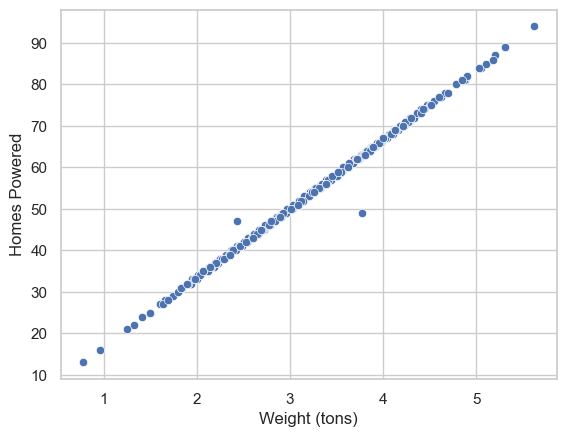

In [83]:
# See how the weight in tons affects the energy output

sns.scatterplot(df1, x = 'Weight (tons)', y = 'Homes Powered')


<function matplotlib.pyplot.show(close=None, block=None)>

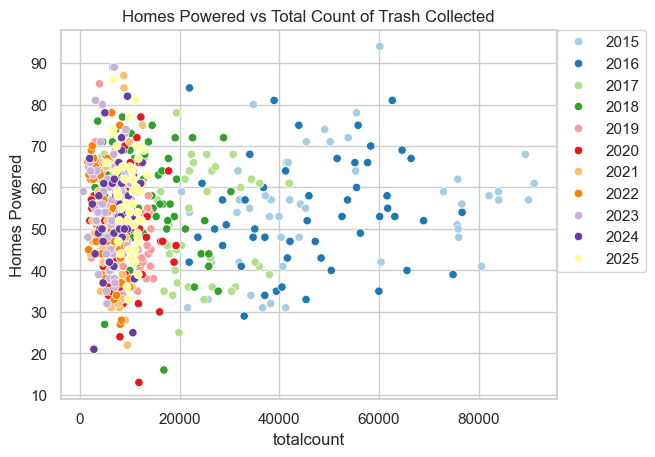

In [106]:
sns.scatterplot(df3, x = 'totalcount', y = 'Homes Powered', hue = "Year", palette = "Paired")
plt.title("Homes Powered vs Total Count of Trash Collected")
plt.legend(bbox_to_anchor=(1,1), loc = "upper left", borderaxespad = 0)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

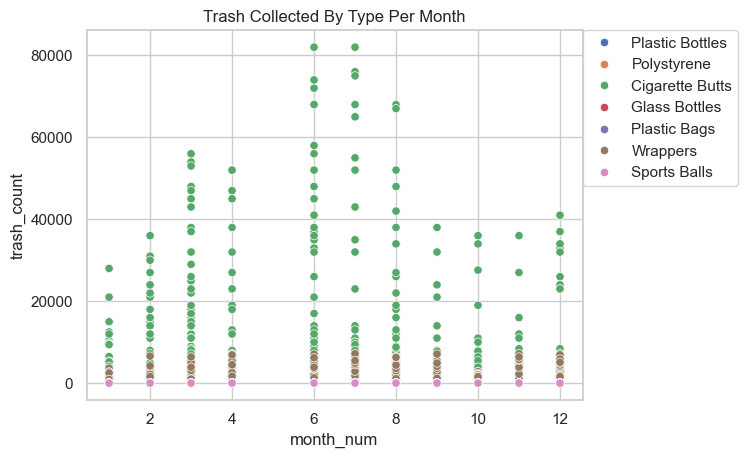

In [84]:
# Does which type of trash is collected change over the year? 

sns.scatterplot(dflong, x = 'month_num', y = 'trash_count', hue = "trash_type")
plt.title("Trash Collected By Type Per Month")
plt.legend(bbox_to_anchor=(1, 1), loc = 'upper left', borderaxespad =0)
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

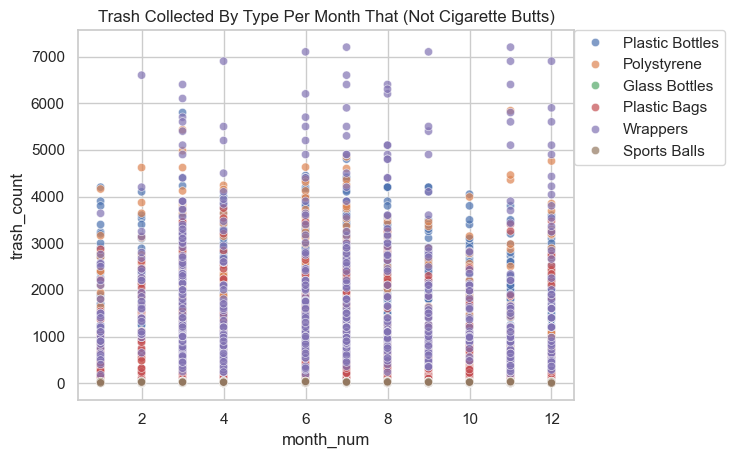

In [85]:
# do that again without cigarettes to see the other categories

df_no_cig = dflong[(dflong['trash_type'] != 'Cigarette Butts')]

sns.scatterplot(df_no_cig, x = 'month_num', y = 'trash_count', hue = "trash_type", alpha = 0.7)
plt.title("Trash Collected By Type Per Month That (Not Cigarette Butts)")
plt.legend(bbox_to_anchor=(1, 1), loc = 'upper left', borderaxespad =0)
plt.show

In [86]:
# how many dumpsters were collected each month -- use the original long format

dumpstercount = df1.groupby(['Year', 'month_num'])['Dumpster'].agg(count = "count")

dumpstercount.head()

count
Year month_num       
2015 2              1
     3              9
     4              6
     6             14
     7              6

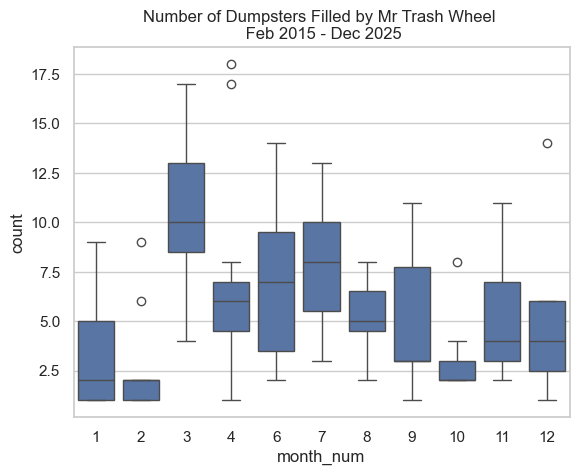

In [87]:
sns.boxplot(dumpstercount, x = 'month_num', y = 'count')
plt.title("Number of Dumpsters Filled by Mr Trash Wheel \n Feb 2015 - Dec 2025")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

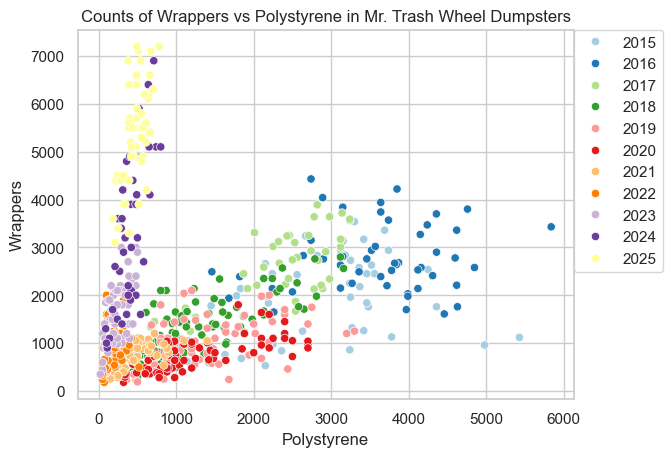

In [63]:
# do wrappers and food containers (Polystyrene) have a relationship?

sns.scatterplot(df1, x = 'Polystyrene', y = 'Wrappers', hue = "Year", palette = "Paired")
plt.title("Counts of Wrappers vs Polystyrene in Mr. Trash Wheel Dumpsters")
plt.legend(bbox_to_anchor=(1, 1), loc = 'upper left', borderaxespad =0)
plt.show



## Model: Predicting Energy Output 

In [130]:
# Full model using all numeric data
features = ['Year', 'month_num', "Weight (tons)", "Volume (cubic yards)","Plastic Bottles", "Polystyrene", "Cigarette Butts", 
                  "Glass Bottles", "Plastic Bags", "Wrappers", "Sports Balls"]

X = df1[features]
y = df1['Homes Powered']

# Scale Data
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

# split! 
X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size = 0.2, random_state = 83)

fullmodel = LinearRegression().fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': features, 
    'Standardized_Weight': fullmodel.coef_}).sort_values(by='Standardized_Weight', key=abs, ascending=False)

print(importance)

print(f"Multiple Regression Test R2: {r2_score(y_test, fullmodel.predict(X_test)):.3f}")


                 Feature  Standardized_Weight
2          Weight (tons)            12.073521
1              month_num            -0.048580
7          Glass Bottles             0.029593
10          Sports Balls            -0.021828
0                   Year             0.021095
6        Cigarette Butts             0.020085
3   Volume (cubic yards)             0.018553
4        Plastic Bottles            -0.011306
5            Polystyrene             0.011245
8           Plastic Bags             0.008594
9               Wrappers            -0.000737
Multiple Regression Test R2: 0.999


In [116]:
# That had a really high R2 value -- it's because of the near perfect linear relationship between weight and homes powered  
# removing Wrappers as the lowest coefficent in the importance table to see if this does anything
features = ['Year', 'month_num', "Weight (tons)", "Volume (cubic yards)","Plastic Bottles", "Polystyrene", "Cigarette Butts", 
                  "Glass Bottles", "Plastic Bags", "Sports Balls"]

X = df1[features]
y = df1['Homes Powered']

# Scale Data
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

# split! 
X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size = 0.2, random_state = 83)

model2 = LinearRegression().fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': features, 
    'Standardized_Weight': model2.coef_}).sort_values(by='Standardized_Weight', key=abs, ascending=False)

print(importance)

print(f"Multiple Regression Test R2: {r2_score(y_test, model2.predict(X_test)):.3f}")

                Feature  Standardized_Weight
2         Weight (tons)            12.073486
1             month_num            -0.048624
7         Glass Bottles             0.029529
9          Sports Balls            -0.021819
0                  Year             0.020304
6       Cigarette Butts             0.019882
3  Volume (cubic yards)             0.018548
4       Plastic Bottles            -0.011227
5           Polystyrene             0.011051
8          Plastic Bags             0.008144
Multiple Regression Test R2: 0.999


In [117]:
# R2 is still 0.999
# remove Plastic bags as lowest coefficent to see if that changes anything
features = ['Year', 'month_num', "Weight (tons)", "Volume (cubic yards)","Plastic Bottles", "Polystyrene", "Cigarette Butts", 
                  "Glass Bottles",  "Sports Balls"]


X = df1[features]
y = df1['Homes Powered']

# Scale Data
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

# split! 
X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size = 0.2, random_state = 83)

model3 = LinearRegression().fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': features, 
    'Standardized_Weight': model3.coef_}).sort_values(by='Standardized_Weight', key=abs, ascending=False)

print(importance)

print(f"Multiple Regression Test R2: {r2_score(y_test, model3.predict(X_test)):.3f}")

                Feature  Standardized_Weight
2         Weight (tons)            12.073551
1             month_num            -0.048621
7         Glass Bottles             0.030533
8          Sports Balls            -0.021643
6       Cigarette Butts             0.020755
3  Volume (cubic yards)             0.019354
0                  Year             0.019232
5           Polystyrene             0.015128
4       Plastic Bottles            -0.011165
Multiple Regression Test R2: 0.999


## PCA 

In [118]:
features = ['Year', 'month_num', "Weight (tons)", "Volume (cubic yards)","Plastic Bottles", "Polystyrene", "Cigarette Butts", 
                  "Glass Bottles", "Plastic Bags", "Sports Balls"]

X = df1[features]
y = df1['Homes Powered']

# preprocessing: scaling! 
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

pca = PCA()
energy = pca.fit_transform(x_scaled)

### Scree Plot

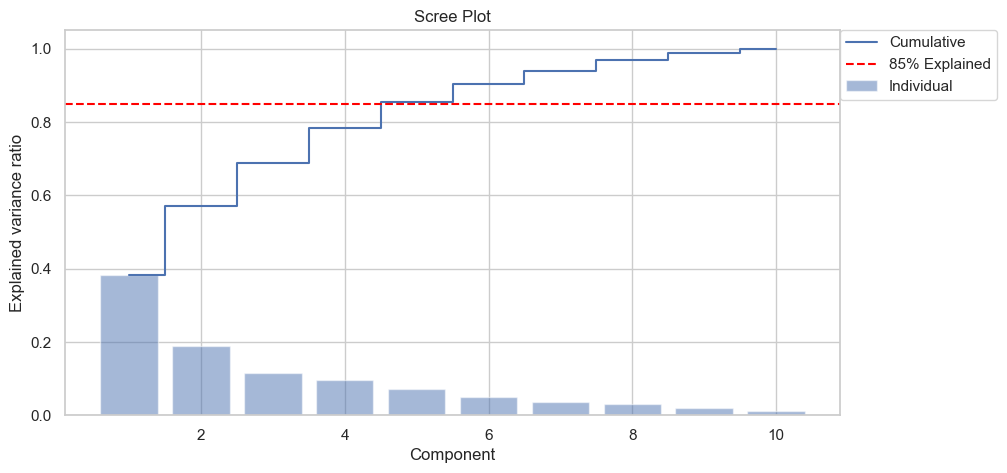

In [121]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.5, label='Individual')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative')
plt.axhline(y = .85, color = 'red', linestyle = 'dashed', linewidth = 1.5, label = '85% Explained')
plt.ylabel('Explained variance ratio'); plt.xlabel('Component'); plt.title('Scree Plot')
plt.legend(bbox_to_anchor=(1, 1), loc = 'upper left', borderaxespad =0); plt.show()

Need 5 PC components

pca_df = pd.DataFrame(data=energy[:,:5], columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

pca_df.head()

### Linear Regression of the 5 PCs

In [131]:
Xpca = pca_df
y = df1["Homes Powered"]

# split the data!
X_trainP, X_testP, y_trainP, y_testP = train_test_split(Xpca, y, test_size=0.2, random_state=83)

pcaregression_model = LinearRegression().fit(X_trainP, y_trainP)


print(f"Multiple Regression Test R2: {r2_score(y_testP, pcaregression_model.predict(X_testP)):.3f}")

Multiple Regression Test R2: 0.975


## Feature Contributions to PCAs: Heatmap

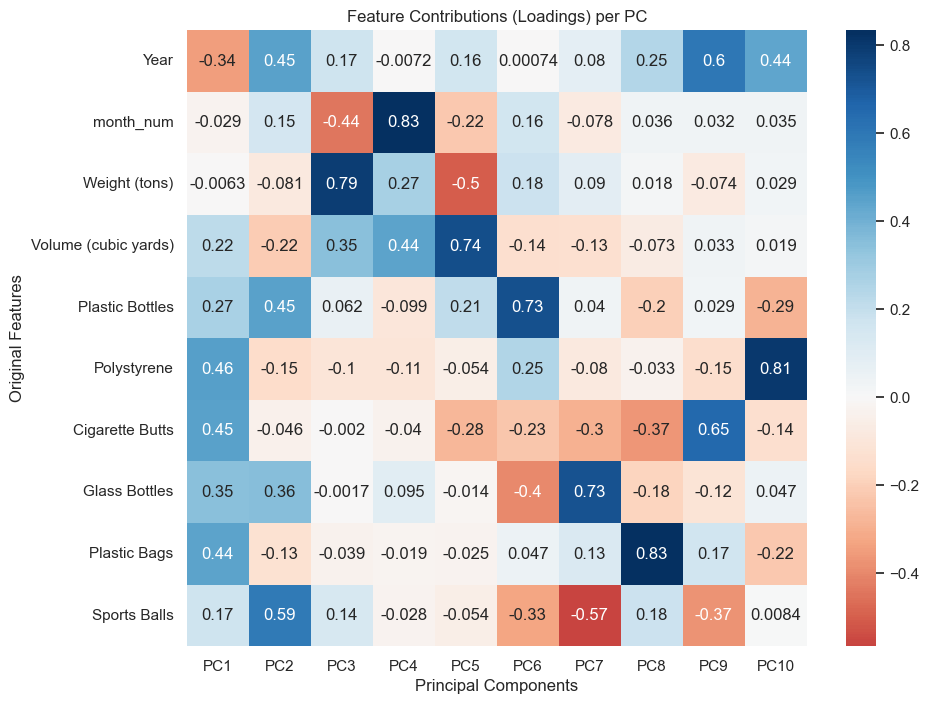

In [133]:
features = ['Year', 'month_num', "Weight (tons)", "Volume (cubic yards)","Plastic Bottles", "Polystyrene", "Cigarette Butts", 
                  "Glass Bottles", "Plastic Bags", "Sports Balls"]

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], # generates column names, first is 1, second is 2, etc
    index=features # uses features as index
)

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Feature Contributions (Loadings) per PC')
plt.ylabel('Original Features')
plt.xlabel('Principal Components')
plt.show()

### Biplot of PC1 and PC2

In [140]:
def draw_biplot(energy, coeff, labels=None):
    # Scale the scores and coefficients to fit on the same plot
    xs = energy[:,0]
    ys = energy[:,1]
    n = coeff.shape[0]
    
    # Scaling factor to normalize dots between -1 and 1
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    
    plt.figure(figsize=(12, 8))
    
    # Plot the Data Points (the scores)
    plt.scatter(xs * scalex, ys * scaley, alpha=0.3, c='yellow')
    
    # Plot the Arrows and Labels (The Coeffs)
    for i in range(n):
        # Draw the arrow
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], 
                  color='firebrick', alpha=0.8, head_width=0.02)
        
 # Add the text label at the tip of the arrow
        if labels is not None:
            plt.text(coeff[i,0] * 1.15, coeff[i,1] * 1.15, 
                     labels[i], color='darkgreen', 
                     ha='center', va='center', fontweight='bold')

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("Biplot: Dots = Dumpsters, Arrows = Features")
    plt.axhline(0, color='black', lw=1, alpha=0.5)
    plt.axvline(0, color='black', lw=1, alpha=0.5)
    plt.grid(alpha=0.3)
    plt.show()
    

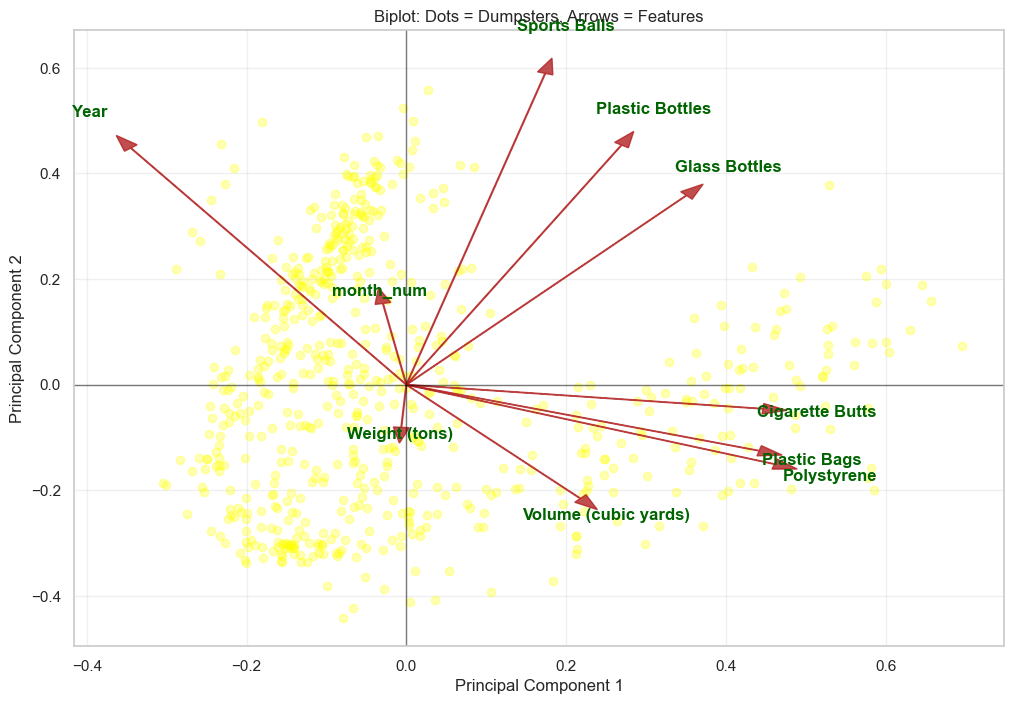

In [141]:
draw_biplot(energy,pca.components_.T, labels=features)